
Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd

import shutil
import time
from datetime import datetime

#concurrent/parallel processing
from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError
from shuffle_methods import random_roll_columns_numba, random_roll_columns_fast, create_shuffled_df_optimized, random_roll_columns, get_mean_postoutcome_stage_activity
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from matlab_obj_to_python import load_matlab_object, check_corrupted_files, truncate_post_outcome_to_15s, label_frame_sections_df, add_task_stage_to_raster_df

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


#### Define file config variables and analysis parameters ####

In [2]:
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")

# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/shuffles/shuffle_run_20251202_124320/config_used.yaml')

In [3]:
#set parameters
data_types = ['spikes', 'dff']
data_type_used = data_types[1] #OR, 'dff'
run_activity_enrichment = True


In [4]:
#get all dataset names
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name] #verify you are using the correct number of dataset 
print(f"Found {len(content_names)} files in {source_dataset_location}")
assert len(content_names) == 35, "Number of datasets does not match expected"
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
    else:
        loaded_objects.append(obj)
        print(f"Loading file {num}/{len(content_names)}: {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames. {obj['dff'].shape} temporal weights ")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    check_corrupted_files(loaded_objects, failed_files)

Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
Loading file 0/35: 10_3_HET_RS1: 150415 cells × 136 frames. (150415, 136) temporal weights 
Loading file 1/35: 10_3_HET_RS2: 97940 cells × 168 frames. (97940, 168) temporal weights 
Loading file 2/35: 10_3_HET_RS3: 108794 cells × 157 frames. (108794, 157) temporal weights 
Loading file 3/35: 13_3_HET_RS1: 191533 cells × 160 frames. (191533, 160) temporal weights 
Loading file 4/35: 13_3_HET_RS2: 108651 cells × 145 frames. (108651, 145) temporal weights 
Loading file 5/35: 13_3_HET_RS3: 128277 cells × 147 frames. (128277, 147) temporal weights 
Loading file 6/35: 13_4_WT_RS1: 153831 cells × 183 frames. (153831, 183) temporal weights 
Loading file 7/35: 13_4_WT_RS2: 106245 cells × 171 frames. (106245, 171) temporal weights 
Loading file 8/35: 13_5_HET_RS1: 229350 cells × 120 frames. (229350, 120) temporal weights 
Loading file 9/35: 13_5_HET_RS2: 141283 cel

#### Extract and Transform Matlab Objects into stage-labeled dataframes

In [5]:
from scipy.ndimage import gaussian_filter1d
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, get_intercol_corrs, read_shuffle_parquet_from_folder, pivot_trial_windows, extract_trial_windows, create_subject_trial_tseries_df

### testing
test_df = dataset_obj_to_df(loaded_objects[0],config, analysis_config,  datatype = 'dff', normalize = 	config['preprocessing']['normalization']) #test 1 dataset
print(test_df.info())
test_df.head(1)

Processed dff of 10_3_HET_RS1: 81825760 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 135487 entries, frame_14928 to frame_150414
Columns: 147 entries, cell_1 to truncated_post
dtypes: Int16(1), bool(2), float32(136), int32(1), object(7)
memory usage: 83.8+ MB
None


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,normalized,datatype,subject_name,geno,session,drop_inactive_cells,trial_num,task_stage,trial_section,truncated_post
frame_14928,10.162713,-0.265766,-0.284692,0.528677,-0.262349,-0.417058,-0.284174,2.295044,-0.16677,-0.280019,...,baseline_zscore,dff,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True


<Figure size 960x720 with 0 Axes>

In [6]:
# Loop over imported subject rasters and create pandas DataFrames
normalize = config['preprocessing']['normalization']
print(f"Applying normalization: {normalize}")
raster_dataframes= transform_all_datasets(loaded_objects,config, analysis_config, datatype = data_type_used, normalize = normalize)

Applying normalization: baseline_zscore
Processed dff of 10_3_HET_RS1: 81825760 bytes
Processed dff of 10_3_HET_RS2: 65815680 bytes
Processed dff of 10_3_HET_RS3: 68322632 bytes
Processed dff of 13_3_HET_RS1: 122581120 bytes
Processed dff of 13_3_HET_RS2: 63017580 bytes
Processed dff of 13_3_HET_RS3: 75426876 bytes
Processed dff of 13_4_WT_RS1: 112604292 bytes
Processed dff of 13_4_WT_RS2: 72671580 bytes
Processed dff of 13_5_HET_RS1: 110088000 bytes
Processed dff of 13_5_HET_RS2: 70641500 bytes
Processed dff of 13_5_HET_RS3: 50825380 bytes
Processed dff of 13_6_WT_RS1: 203608028 bytes
Processed dff of 13_6_WT_RS2: 143185776 bytes
Processed dff of 13_8_HET_RS1: 102753144 bytes
Processed dff of 13_8_HET_RS2: 92035856 bytes
Processed dff of 13_8_HET_RS3: 123681648 bytes
Processed dff of 14_2_WT_RS1: 79038840 bytes
Processed dff of 14_2_WT_RS2: 85285472 bytes
Processed dff of 15_1_HET_RS1: 104717520 bytes
Processed dff of 15_1_HET_RS2: 92949180 bytes
Processed dff of 15_1_HET_RS3: 6662674

#### Circular shuffle of frame labels 

In [ ]:
# Option 1: Global seed sequence across all subjects
run_shuffles = False  #set to True to run shuffles
n_shuf_per_subject = config['shuffles']['n_shuffles_per_subject'] #default = 5000
## Configuration #200 minutes for 5000 shuffles/subject on 14 cores
n_jobs=  config['shuffles']['n_cores'] -2 #base =  psutil.cpu_count(logical=False)-2  #leave 2 cores free
base_seed = config['shuffles']['base_seed'] #default: 42

#set shuffle storage data folder
run_output_folder = results_dir / Path(f"{data_type_used}_{normalize}_norm_ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

#set RNG info 
n_subjects = len(raster_dataframes)
rng_master = np.random.default_rng(base_seed) # Generate random seeds once at the start
seed_min, seed_max = 0, 2**31 # Generate N random seeds (each will be different)

print(f"Total subjects: {n_subjects}, Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles to create: {n_subjects * n_shuf_per_subject}")

## main shuffle body
all_subject_shuffles = {} # Process each subject with their allocated seed range
if run_shuffles:
    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        subject_seeds = rng_master.integers(0,seed_max, size=n_shuf_per_subject) # Allocate unique seed range for this subject
        # Run parallel shuffles for this subject- oputputs lists
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(delayed(create_shuffled_df_optimized)((subject_raster_df, cell_col, int(seed))) for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)
        all_shuffle_means = all_shuffle_means.assign(**{'date_saved': datetime.now().strftime("%Y-%m-%d %H:%M"),
                                                        'n_shuffles': n_shuf_per_subject, 'subject_name': subject_name}) 
        all_subject_shuffles[subject_name] = all_shuffle_means
        output_shuff.to_parquet(shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet"))   #save file
        print(f" Completed + saved {len(output_shuff)} shuffles")
    print(f"\nAll {n_subjects} subjects processed. Saving shuffled mean activity DFs to {shuffle_storage_folder}")        

 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_02-Dec-2025_5000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_02-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject
Total subjects: 35, Shuffles per subject: 5000
Total shuffles to create: 175000


#### Extract parquet files and save run record

In [8]:
def log_shuffle_run(results_dir: Path, shuffle_storage_folder: Path, 
                    n_shuf_per_subject: int, n_subjects: int, base_seed: int) -> None:
    """Log a completed shuffle run to the run log CSV.
    Parameters:
    - results_dir: Directory containing the run log
    - shuffle_storage_folder: Folder where shuffle parquet files were saved
    - n_shuf_per_subject: Number of shuffles per subject
    - n_subjects: Number of subjects processed
    - base_seed: Random seed used
    """
    shuffle_run_log_path = results_dir / "shuffle_run_log.csv"
    run_info = {'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),'shuffle_folder': str(shuffle_storage_folder),'n_shuffles_per_subject': n_shuf_per_subject,'n_subjects': n_subjects,'base_seed': base_seed}
    # Load existing log or create new one
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        run_log_df = pd.concat([run_log_df, pd.DataFrame([run_info])], ignore_index=True)
    else:
        run_log_df = pd.DataFrame([run_info])
    # Save updated log
    run_log_df.to_csv(shuffle_run_log_path, index=False)
    print(f"Saved latest shuffle run to {shuffle_run_log_path}")

def load_latest_shuffle_run(results_dir: Path, shuffle_storage_folder= None):
    """    Load shuffles from the most recent run in the log.
    Parameters: results_dir: Directory containing the run log
    (Optional) shuffle_storage_folder=
    
    Returns:
    - shuffle_storage_folder: Path to the shuffle folder
    - all_subject_shuffles: Loaded shuffle data
    - latest_run: Series with run metadata (timestamp, n_shuffles, etc.)
    
    Raises: FileNotFoundError: If no shuffle run log exists    """

    shuffle_run_log_path = results_dir / "shuffle_run_log.csv"
    if not shuffle_run_log_path.exists():
        raise FileNotFoundError(f"No shuffle run log found at {shuffle_run_log_path}")    
    # Load log and get most recent run
    run_log_df = pd.read_csv(shuffle_run_log_path)
    latest_run = run_log_df.iloc[-1]
    if shuffle_storage_folder == None:
        shuffle_storage_folder = Path(latest_run['shuffle_folder'])

    print(f"Loading shuffles from Timestamp: {latest_run['timestamp']} | {latest_run['n_shuffles_per_subject']} Shuffles")
    print(f"  Folder: {shuffle_storage_folder}")
    # Load all parquet files from that folder
    all_subject_shuffles = read_shuffle_parquet_from_folder(shuffle_storage_folder)
    return shuffle_storage_folder, all_subject_shuffles, latest_run

if run_shuffles: # After generating shuffles...
    log_shuffle_run(results_dir, shuffle_storage_folder, n_shuf_per_subject, len(raster_dataframes), base_seed)
else:
    shuffle_storage_folder, all_subject_shuffles, latest_run = load_latest_shuffle_run(results_dir)

Loading shuffles from Timestamp: 2025-11-22 12:31:22 | 5000 Shuffles
  Folder: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_22-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_R

#### Given shuffle array, run enrichment detection

In [11]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)
#optional- save ensemble info as parquet
if 'data_type' not in all_ensembles.columns:# if data_type col isn't present in the ensemble matrix, add it
    all_ensembles['data_type'] = data_type_used
new_python_ens_file = run_output_folder / Path(f"{data_type_used}_postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
all_ensembles.to_parquet(new_python_ens_file)

Processing subject: 10_3_HET_RS1
Processing subject: 10_3_HET_RS2
Processing subject: 10_3_HET_RS3
Processing subject: 13_3_HET_RS1


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Processing subject: 13_3_HET_RS2
Processing subject: 13_3_HET_RS3
Processing subject: 13_4_WT_RS1
Processing subject: 13_4_WT_RS2
Processing subject: 13_5_HET_RS1
Processing subject: 13_5_HET_RS2
Processing subject: 13_5_HET_RS3
Processing subject: 13_6_WT_RS1
Processing subject: 13_6_WT_RS2
Processing subject: 13_8_HET_RS1
Processing subject: 13_8_HET_RS2
Processing subject: 13_8_HET_RS3
Processing subject: 14_2_WT_RS1
Processing subject: 14_2_WT_RS2
Processing subject: 15_1_HET_RS1
Processing subject: 15_1_HET_RS2
Processing subject: 15_1_HET_RS3
Processing subject: 5_3_WT_RS1
Processing subject: 5_3_WT_RS2
Processing subject: 6_2_WT_RS1
Processing subject: 6_2_WT_RS2
Processing subject: 7_2_WT_RS1
Processing subject: 7_4_WT_RS1
Processing subject: 7_5_WT_RS1
Processing subject: 7_5_WT_RS2
Processing subject: 7_6_HET_RS1
Processing subject: 7_6_HET_RS2
Processing subject: 7_6_HET_RS3
Processing subject: 9_3_HET_RS1
Processing subject: 9_3_HET_RS2
Processing subject: 9_3_HET_RS3


#### Within python latest shuffle run, compare within chunk stability


In [ ]:
def chunk_shuffles_by_subject(all_subject_shuffles: Dict[str, pd.DataFrame], raster_dataframes: Dict[str, pd.DataFrame], chunk_size: int = 1000) -> pd.DataFrame:
    """ Chunk shuffles by subject into smaller sets for enrichment analysis.
    Inputs:
    all_subject_shuffles : Dict of subject_name to shuffled mean activity DataFrame
    raster_dataframes : Dict of subject_name to raster DataFrame
    chunk_size : number of unique seeds per chunk
    Returns: pd.DataFrame of combined enrichment results across all subject-chunks"""
    # Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
    print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
    chunked_ensemble_results = []
    # Loop over each subject
    for subject_name, shuffle_df in all_subject_shuffles.items():
        # Get unique seeds for THIS subject
        subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
        n_seeds = len(subject_unique_seeds)
        n_chunks = n_seeds // chunk_size
        print(f"\n=== Processing subject: {subject_name}. total seeds: {n_seeds}, {n_chunks} chunks ===")
        
        # Get corresponding raster data
        subject_raster_df = raster_dataframes[subject_name]
        cell_col = [c for c in subject_raster_df.columns if c.startswith('cell_')]
        
        # Loop over chunks for this subject
        for chunk_idx in range(n_chunks):
            # Get specific seeds for this chunk
            start_idx = chunk_idx * chunk_size
            end_idx = (chunk_idx + 1) * chunk_size
            chunk_seeds = subject_unique_seeds[start_idx:end_idx]
            chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
            # Run enrichment analysis for this subject-chunk
            chunk_ensembles = get_cell_stage_enrichment(all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, cell_col=cell_col,n_shuf_per_subject=len(chunk_seeds))
            # Add metadata
            chunked_ensemble_results.append(chunk_ensembles.assign(**{'subject_name': subject_name,'chunk_index': chunk_idx, 'chunk_seed_min': chunk_seeds[0],'chunk_seed_max': chunk_seeds[-1],'n_seeds_in_chunk': len(chunk_seeds)}))

    # Combine all subject-chunk results
    all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)
    print(f"Processed {all_chunked_ensembles['subject_name'].nunique()} Subjects into {all_chunked_ensembles.shape} shaped DF")
    print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")
    return all_chunked_ensembles

## pivot chunked ensembles activation and plot heatmap
def get_pivoted_enrichment_heatmap(all_chunked_ensembles: pd.DataFrame, pivot_values = 'enriched') -> pd.DataFrame:
    """ Pivot chunked ensemble enrichment results and plot heatmap of correlations.
    Inputs: all_chunked_ensembles : DataFrame with columns ['subject_name', 'task_stage', 'cell', 'chunk_index', 'enriched']
    Returns: Pivoted DataFrame of enrichment by chunk"""

    enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values=pivot_values,aggfunc='first')
    enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
    enriched_by_chunk=enriched_by_chunk.reset_index()
    return enriched_by_chunk

In [15]:
all_chunked_ensembles = chunk_shuffles_by_subject(all_subject_shuffles, raster_dataframes, chunk_size=1000)

Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1 ===
10_3_HET_RS1 total seeds: 5000, 5 chunks

=== Processing subject: 10_3_HET_RS2 ===
10_3_HET_RS2 total seeds: 5000, 5 chunks

=== Processing subject: 10_3_HET_RS3 ===
10_3_HET_RS3 total seeds: 5000, 5 chunks

=== Processing subject: 13_3_HET_RS1 ===
13_3_HET_RS1 total seeds: 5000, 5 chunks


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(



=== Processing subject: 13_3_HET_RS2 ===
13_3_HET_RS2 total seeds: 5000, 5 chunks

=== Processing subject: 13_3_HET_RS3 ===
13_3_HET_RS3 total seeds: 5000, 5 chunks

=== Processing subject: 13_4_WT_RS1 ===
13_4_WT_RS1 total seeds: 5000, 5 chunks

=== Processing subject: 13_4_WT_RS2 ===
13_4_WT_RS2 total seeds: 5000, 5 chunks

=== Processing subject: 13_5_HET_RS1 ===
13_5_HET_RS1 total seeds: 5000, 5 chunks

=== Processing subject: 13_5_HET_RS2 ===
13_5_HET_RS2 total seeds: 5000, 5 chunks

=== Processing subject: 13_5_HET_RS3 ===
13_5_HET_RS3 total seeds: 5000, 5 chunks

=== Processing subject: 13_6_WT_RS1 ===
13_6_WT_RS1 total seeds: 5000, 5 chunks

=== Processing subject: 13_6_WT_RS2 ===
13_6_WT_RS2 total seeds: 5000, 5 chunks

=== Processing subject: 13_8_HET_RS1 ===
13_8_HET_RS1 total seeds: 5000, 5 chunks

=== Processing subject: 13_8_HET_RS2 ===
13_8_HET_RS2 total seeds: 5000, 5 chunks

=== Processing subject: 13_8_HET_RS3 ===
13_8_HET_RS3 total seeds: 5000, 5 chunks

=== Process

#### import raw shuffle data for DFF and spikes, to compare shuffle chunk similarity

In [17]:
spikes_shuffle_path = results_dir / Path(f"spikes_ensemble_detection_20-Nov-2025_5000 shuffles/shuffled_dfs_5000_per_subject")
print(f"Loading shuffles from {spikes_shuffle_path}")
all_shuffles_spikes =  read_shuffle_parquet_from_folder(spikes_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_spikes = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'raster', normalize = 'none')
all_chunk_ens_spikes = chunk_shuffles_by_subject(all_shuffles_spikes, raster_dataframes_spikes, chunk_size=1000)
enriched_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes)
enriched_by_chunk_spikes.head()


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\spikes_ensemble_detection_20-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
Processed raster of 10_3_HET_RS1: 1

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


In [44]:
def plot_stage_correlation_heatmaps(enrich_compared_df: pd.DataFrame, 
                                   stage_names: list, 
                                   merge_chunk_col: list,
                                   value_compared: str,
                                   axes: np.ndarray,
                                   grid_shape: tuple = (2, 3),
                                   vmin: float = 0.5,
                                   cmap: str = 'viridis') -> None:
    """Plot correlation heatmaps for each task stage on a subplot grid."""
    nrows, ncols = grid_shape
    
    for s, stage in enumerate(stage_names):
        ax = axes.flatten()[s]
        row, col = s // ncols, s % ncols
        
        # Compute and plot correlation for this stage
        stage_vals = enrich_compared_df[enrich_compared_df['task_stage'] == stage][merge_chunk_col].corr()
        sns.heatmap(stage_vals, vmin=vmin, cmap=cmap, ax=ax)
        
        # Remove ticks if not on edges
        if col != 0: ax.set_yticks([])
        if row != nrows - 1: ax.set_xticks([])
        
        ax.set_title(f"{stage.replace('_', ' ')}: {value_compared} correlations")

Figure saved: dff_vs_spikes_ensemble_membership_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


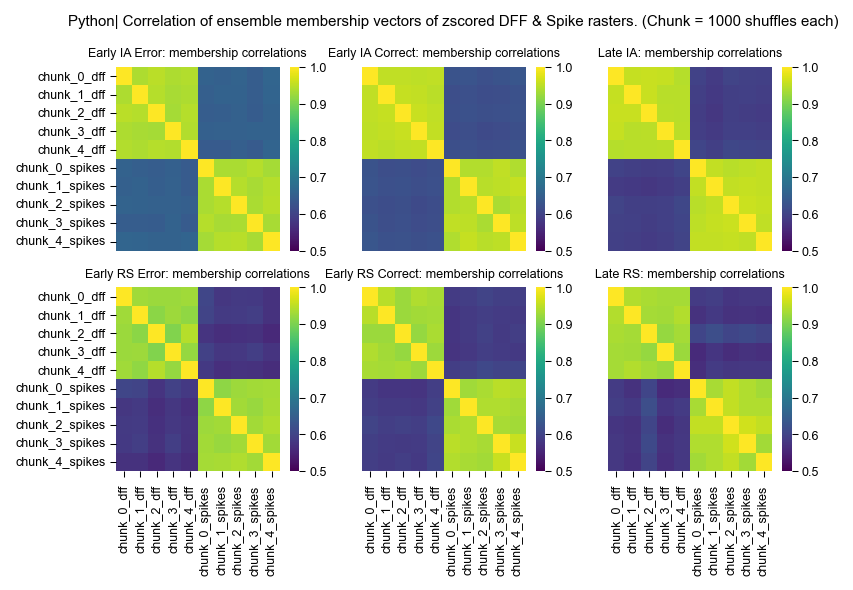

In [ ]:
# #merge enrich by chunk spikes and enriched by chunk dff
enriched_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunked_ensembles)
merged_enriched_chunks = pd.merge(enriched_by_chunk_dff, enriched_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
# Plot correlation heatmaps
value_compared = "membership"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merged_enriched_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merged_enriched_chunks.columns if 'chunk_' in c], value_compared=value_compared, axes = axes)
fig.suptitle(f"Python| Correlation of ensemble {value_compared} vectors of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes_ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

Figure saved: dff_vs_spikes_ensemble_p-value_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


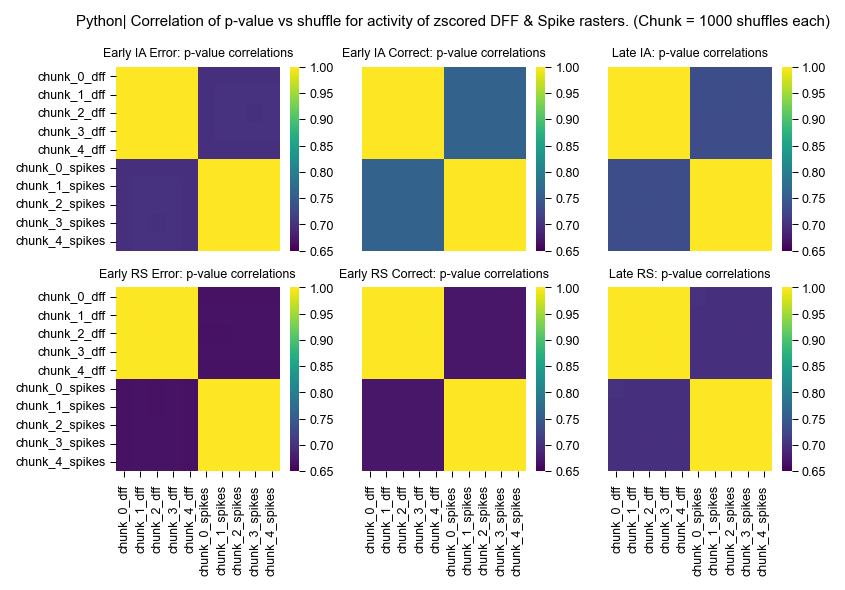

In [63]:
#use pvalue for corr 
pval_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes, pivot_values = 'percent_shuffle >= real')
pval_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunked_ensembles, pivot_values = 'percent_shuffle >= real')
merge_pval_chunks = pd.merge(pval_by_chunk_dff, pval_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))

# Plot correlation heatmaps
value_compared = "p-value"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merge_pval_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merge_pval_chunks.columns if 'chunk_' in c], value_compared=value_compared, vmin = 0.65, axes = axes)
fig.suptitle(f"Python| Correlation of {value_compared} vs shuffle for activity of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes_ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

#### import both DFF & spike ensemble parquets


In [22]:
# import DFF ensemble matrix 
dff_ens_path = results_dir / Path(r"dff_ensemble_detection_21-Nov-2025_5000 shuffles\dff_postoutcome_python_ensembles_5000_shuff_21-Nov-2025_.parquet")
dff_ens = pd.read_parquet(dff_ens_path)
if 'data_type' not in dff_ens.columns:
    dff_ens['data_type'] = 'dff'
print(dff_ens.info())
#get ensemble info from canon df
dff_ens.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40640 entries, 0 to 40639
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               40640 non-null  object 
 1   cell                     40640 non-null  object 
 2   percentile_95            40640 non-null  float64
 3   mean                     40640 non-null  float32
 4   enriched                 40640 non-null  bool   
 5   percent_shuffle >= real  40640 non-null  float64
 6   subject_name             40640 non-null  object 
 7   neuron_id                40640 non-null  object 
 8   date_made                40640 non-null  object 
 9   n_shuffles               40640 non-null  int64  
 10  data_type                40640 non-null  object 
dtypes: bool(1), float32(1), float64(2), int64(1), object(6)
memory usage: 3.0+ MB
None


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
40637,Late_IA,cell_215,0.001142,0.000316,False,0.9184,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff
40638,Late_RS,cell_215,0.001239,0.001194,False,0.0616,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff
40639,truncated_post_outcome,cell_215,0.000627,0.000333,False,0.9992,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff


In [23]:
#import last spikes ensemble matrix for comparison
spikes_ens_path = results_dir / Path(r"spikes_ensemble_detection_20-Nov-2025_5000 shuffles\spikes_postoutcome_python_ensembles_5000_shuff_20-Nov-2025_.parquet")
spikes_ens = pd.read_parquet(spikes_ens_path)
if 'data_type' not in spikes_ens.columns:
    spikes_ens['data_type'] = 'spikes'
print(spikes_ens.info())
spikes_ens.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40640 entries, 0 to 40639
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               40640 non-null  object 
 1   cell                     40640 non-null  object 
 2   percentile_95            40640 non-null  float64
 3   mean                     40640 non-null  float64
 4   enriched                 40640 non-null  bool   
 5   percent_shuffle >= real  40640 non-null  float64
 6   subject_name             40640 non-null  object 
 7   neuron_id                40640 non-null  object 
 8   date_made                40640 non-null  object 
 9   n_shuffles               40640 non-null  int64  
 10  data_type                40640 non-null  object 
dtypes: bool(1), float64(3), int64(1), object(6)
memory usage: 3.1+ MB
None


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
40637,Late_IA,cell_215,0.022033,0.000000,False,1.0000,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes
40638,Late_RS,cell_215,0.025000,0.017500,False,0.1106,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes
40639,truncated_post_outcome,cell_215,0.007345,0.000332,False,0.9992,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes


In [24]:
## pivot both enrichment vectors, then merge
spikes_ens_matrix = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
dff_ens_matrix = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
compare_spike_dff_ens = spikes_ens_matrix.merge(dff_ens_matrix, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_ens.info())
compare_spike_dff_ens.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5961 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5961 non-null   float64
 1   Early_IA_Error_spikes          4874 non-null   float64
 2   Early_RS_Correct_spikes        5961 non-null   float64
 3   Early_RS_Error_spikes          5961 non-null   float64
 4   Late_IA_spikes                 5961 non-null   float64
 5   Late_RS_spikes                 5961 non-null   float64
 6   truncated_post_outcome_spikes  5961 non-null   float64
 7   Early_IA_Correct_dff           5961 non-null   float64
 8   Early_IA_Error_dff             4874 non-null   float64
 9   Early_RS_Correct_dff           5961 non-null   float64
 10  Early_RS_Error_dff             5961 non-null   float64
 11  Late_IA_dff                    5961 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-10,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
df = compare_spike_dff_ens
correlations = {stage: df[stage+"_spikes"].corr(df[stage + '_dff']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.643866
Early_IA_Correct     0.617139
Late_IA              0.579809
Early_RS_Error       0.575530
Early_RS_Correct     0.587447
Late_RS              0.578939


In [26]:
## pivot both p-value matrices, then merge
spikes_ens_pval = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
dff_ens_pval = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
compare_spike_dff_p = spikes_ens_pval.merge(dff_ens_pval, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_p.info())
compare_spike_dff_p.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5961 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5961 non-null   float64
 1   Early_IA_Error_spikes          5961 non-null   float64
 2   Early_RS_Correct_spikes        5961 non-null   float64
 3   Early_RS_Error_spikes          5961 non-null   float64
 4   Late_IA_spikes                 5961 non-null   float64
 5   Late_RS_spikes                 5961 non-null   float64
 6   truncated_post_outcome_spikes  5961 non-null   float64
 7   Early_IA_Correct_dff           5961 non-null   float64
 8   Early_IA_Error_dff             5961 non-null   float64
 9   Early_RS_Correct_dff           5961 non-null   float64
 10  Early_RS_Error_dff             5961 non-null   float64
 11  Late_IA_dff                    5961 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,1.0000,0.0008,1.0,1.0000,1.0000,1.0,0.1388,0.4536,0.0040,0.2276,0.6784,0.4888,0.7558,0.0696
10_3_HET_RS1-10,0.1424,0.0046,1.0,0.0972,0.2986,1.0,0.0002,0.1632,0.0152,0.8634,0.0508,0.3794,0.9782,0.0008
10_3_HET_RS1-100,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.9936,0.9896,0.8938,0.9890,0.8388,0.9968,0.9750,0.9978


In [27]:
corr_df = get_intercol_corrs(compare_spike_dff_p, stage_names, suffix1="_spikes", suffix2="_dff")
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.779182
Early_IA_Correct     0.745727
Late_IA              0.721740
Early_RS_Error       0.654836
Early_RS_Correct     0.662784
Late_RS              0.682847


#### Threshold time-series df to remove 0 

In [28]:
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import annotate_csv, run_min_max_norm_on_timeseries


In [141]:
#for concordance with previous code, need to label the stage col as 'task_stage_vec
stage_col = 'task_phase_vec'

# ## main time-series df creation function for datasets processed in python
# def create_subject_trial_tseries_df(input_df: pd.DataFrame,
#                                     ens_matrix: pd.DataFrame,
#                                     window_to_bin = 5,
#                                     n_sec_to_rotate = 0,
#                                     cell_col = 'cell',
#                                     cols_to_drop= None,
#                                     stage_col = 'task_phase_vec',
#                                     stage_names = None,
#                                     ) -> pd.DataFrame:
#     """ Create trial-cell time-series DataFrame for one subject, with ensemble info joined. For python native created dfs
#     Inputs:
#     raster_df : DataFrame with one row per frame
#     """
#     #default args
#     if cols_to_drop is None:
#         cols_to_drop = ['threshold_with_shuffle','peak_dff_threshold_percentile','drop_low_value_peak_events','cutoff_filter','peak_event_cutoff_percentile']   
#     if stage_names is None:
#         stage_names = ['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct','Late_RS']
        
#     # extract trial windows from df, removing excess frames
#     trim_df = extract_trial_windows(input_df,pre_frames=config['timeseries']['pre_frames'], post_frames= config['timeseries']['post_frames'])
#     #reshape df into long format: one row per trial-cell, columns = time-series frames
#     outcome_post = pivot_trial_windows(trim_df).rename(columns={'task_stage': stage_col})
#     outcome_post['neuron_id'] = outcome_post['subject_name'] + '-' + outcome_post[cell_col].str.replace('cell_','') 
#     outcome_post =outcome_post.drop([x for x in cols_to_drop if x in outcome_post], axis = 1).dropna(subset = [stage_col])
#     annotate_csv(outcome_post, 'subject_name')

#     ## begin preprocess- bin and rotate timeseries 
#     outcome_post = bin_rotate_timeseries(outcome_post, window_size = window_to_bin, rotate_by = n_sec_to_rotate)
#     outcome_post = outcome_post.join(ens_matrix, on='neuron_id', how='left', rsuffix='_ens') #join dff timeseries with ensemble info
#     #drop time-series not belonging to any task stage , aka the 0 task stage 
#     outcome_post['any_enrichment']= outcome_post[stage_names].sum(axis = 1)
#     outcome_post = outcome_post[outcome_post[stage_col].isin(stage_names)]
#     trial_tseries_df_raw = add_enriched_in_curr_phase_col(outcome_post, stage_col)
#     return trial_tseries_df_raw
# # 


def normalize_tseries_df(trial_tseries_df_raw: pd.DataFrame,
                          n_end_timebins_to_drop = config['timeseries']['n_end_timebins_to_drop'], #default = 0,
                          n_start_timebins_to_drop = config['timeseries']['n_start_timebins_to_drop'], #default = 8,
                          name_col: str = 'subject_name',
                          neuron_id_col: str = 'neuron_id',
                          ) -> pd.DataFrame:
    """ Normalize trial time-series DataFrame based on normalization type.
    Inputs:
    trial_tseries_df_raw : DataFrame with raw time-series data (ALREADY BINNED)
    hyper_param_dict : dictionary of hyperparameters
    outcome_post : DataFrame with outcome post data

    Returns: Normalized trial time-series DataFrame
    """
    #get normalization info for curr df
    normed = trial_tseries_df_raw['normalized'].unique()[0]
    if normed == 'none':
        use_min_max_norm = True 
    else:
        use_min_max_norm = False
    print(f" Data Normalization type: {normed} | Applying min-max norm? {use_min_max_norm} ")

    numeric_col = get_numeric_cols_timeseries(trial_tseries_df_raw, " to ") 
    #is min-max norm run BEFORE or AFTER bin dropping? 
    trial_tseries_df_norm = run_min_max_norm_on_timeseries(use_min_max_norm, trial_tseries_df_raw, [name_col, neuron_id_col], numeric_col, 'max_trial_val') #min_max_norm = True

    #get mean of each trial- IS this run BEFORE or AFTER norm? 
    trial_tseries_df_norm['mean_rate'] =trial_tseries_df_norm[[c for c in numeric_col if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
    trial_tseries_df_norm['active_in_trial'] =trial_tseries_df_norm['mean_rate']>0

    #OPTIONAL- drop N bins from start and M bins from end of time-series
    #first, check if you're pre-truncated the data (e.g. already only sliced 3 seconds before outcome)
    neg_timebins = [c for c in numeric_col if "-" in c]
    if len(neg_timebins) <4*3+1: #if you only have 1 second or so of pre-outcome data, you've already sliced 
        n_start_timebins_to_drop = 0
    trial_tseries_df_norm = drop_end_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_end_timebins_to_drop = n_end_timebins_to_drop )
    trial_tseries_df_norm = drop_start_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_start_timebins_to_drop =n_start_timebins_to_drop)
    return trial_tseries_df_norm

def normalize_all_subject_tseries_dfs(raster_base_dfs: Dict[str, pd.DataFrame],
                                      config = config, 
                                      n_end_timebins_to_drop = 0,
                                      n_start_timebins_to_drop = 8,
                                      name_col: str = 'subject_name',
                                      neuron_id_col: str = 'neuron_id',
                                      ) -> pd.DataFrame:
    """ Normalize all subject trial time-series DataFrames.
    Inputs:     raster_base_dfs : Dict of subject_name to raw full recording matrix DataFrame
    optional settings for time-series normalization that equal defaults, so left un input

    Returns: concat. dataframe of subject_name to normalized trial time-series DataFrame
    """

    raster_timeseries =[]
    for name, raster_df in raster_base_dfs.items():
        print(f" Reshaping tseries of {name}: {raster_df.shape}")    
        subj_trial_tseries_df_raw= create_subject_trial_tseries_df(raster_df, dff_ens_matrix, config = config)
        subj_trial_tseries_df_norm= normalize_tseries_df(subj_trial_tseries_df_raw)
        raster_timeseries.append(subj_trial_tseries_df_norm)
    trial_tseries_df_norm = pd.concat(raster_timeseries)
    return trial_tseries_df_norm

In [142]:
trial_tseries_df_norm = normalize_all_subject_tseries_dfs(raster_dataframes, config = config)
trial_tseries_df_norm


 Reshaping tseries of 10_3_HET_RS1: (135487, 147)
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 60
rem_frames: 0
 Moving numeric coluns by 0 bins
 Data Normalization type: baseline_zscore | Applying min-max norm? False 
Dropping 0 bins from end: []
Dropping 0 bins from start: []
 Reshaping tseries of 10_3_HET_RS2: (85240, 179)
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 60
rem_frames: 0
 Moving numeric coluns by 0 bins
 Data Normalization type: baseline_zscore | Applying min-max norm? False 
Dropping 0 bins from end: []
Dropping 0 bins from start: []
 Reshaping tseries of 10_3_HET_RS3: (90423, 168)
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 60
rem_frames: 0
 Moving numeric coluns by 0 bins
 Data Normalization type: baseline_zscore | Applying min-max norm? False 
Dropping 0 bins from end: []
Dropping 0 bins from start: []
 Reshaping tseries of 13_3_HET_RS1: (174869, 171)
binning data- post. # post-outcome frames: 300

,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,mean_rate,active_in_trial
0,1,cell_1,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-1,1,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,False,-0.233417,False
1,1,cell_10,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-10,1,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,False,-0.280019,False
2,1,cell_100,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-100,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,-0.298105,False
3,1,cell_101,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-101,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,-0.434057,False
4,1,cell_102,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-102,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,False,-0.267789,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8165,38,cell_95,9_3_HET_RS3,RS3,HET,Late_RS,baseline_zscore,dff,9_3_HET_RS3-95,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,0.210070,True
8166,38,cell_96,9_3_HET_RS3,RS3,HET,Late_RS,baseline_zscore,dff,9_3_HET_RS3-96,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,False,-0.413174,False
8167,38,cell_97,9_3_HET_RS3,RS3,HET,Late_RS,baseline_zscore,dff,9_3_HET_RS3-97,3,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,False,-0.061426,False
8168,38,cell_98,9_3_HET_RS3,RS3,HET,Late_RS,baseline_zscore,dff,9_3_HET_RS3-98,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,-0.213799,False


In [132]:

# get mean time-series value
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")  #update post drop
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['subject_name', 'neuron_id','geno_day', stage_col], numeric_col) 
unit_mean_tseries


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\preprocess_data.py:235: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  cell_avg_stage_tseries['max_val_tbin']= cell_avg_stage_tseries.loc[:,[c for c in cell_avg_stage_tseries.columns if "to" in c]].idxmax(axis = 1)


,subject_name,neuron_id,geno_day,task_phase_vec,-1.0s to -0.75s,-0.75s to -0.5s,-0.5s to -0.25s,-0.25s to -0.0s,0.0s to 0.25s,0.25s to 0.5s,...,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,mean_rate,active_in_trial,max_val,max_val_tbin
0,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Correct,0.923755,0.727587,0.606845,0.573206,0.475119,0.384726,...,0.0,0.0,0.0,0.0,1.0,False,-0.153341,False,0.923755,-1.0s to -0.75s
1,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Error,-0.213771,-0.226000,-0.233417,-0.233417,-0.233417,-0.233417,...,0.0,0.0,0.0,0.0,1.0,True,15.303195,True,23.894199,12.5s to 12.75s
2,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Correct,2.363398,2.305951,2.039729,1.944668,1.808385,1.696944,...,0.0,0.0,0.0,0.0,1.0,False,0.224163,True,2.363398,-1.0s to -0.75s
3,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Error,-0.233417,-0.233417,-0.233417,-0.233417,-0.233417,-0.233417,...,0.0,0.0,0.0,0.0,1.0,False,-0.232603,False,-0.211073,3.5s to 3.75s
4,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Late_IA,0.509771,0.437228,0.381712,0.481910,0.498577,0.335376,...,0.0,0.0,0.0,0.0,1.0,False,-0.126884,False,0.509771,-1.0s to -0.75s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33732,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_IA_Error,-0.133801,0.041956,-0.188911,-0.464621,-0.442928,-0.465726,...,0.0,0.0,0.0,0.0,0.0,False,-0.424521,False,0.041956,-0.75s to -0.5s
33733,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Correct,-0.404872,-0.294553,-0.345455,-0.312699,-0.392900,-0.414664,...,0.0,0.0,0.0,0.0,0.0,False,-0.315641,False,0.143792,8.0s to 8.25s
33734,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Error,0.690022,0.156748,-0.050995,-0.143176,-0.088702,0.254124,...,0.0,0.0,0.0,0.0,0.0,False,0.015789,True,0.898590,3.0s to 3.25s
33735,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_IA,0.139083,-0.057148,-0.114513,-0.320696,-0.095593,-0.338380,...,0.0,0.0,0.0,0.0,0.0,False,-0.011895,True,0.943868,3.25s to 3.5s


In [32]:
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['neuron_id'].nunique()
print(n_total_units)
print(n_total_units.sum())
#save filename with data type and date info
save_name = results_dir / Path(f"trial_timeseries_{data_type_used}_{datetime.now().strftime("%Y-%m-%d %H")}.parquet")
trial_tseries_df_norm.to_parquet(save_name)


geno_day
Het CLNZ        1094
Het VEH         1094
Het postCLNZ    1177
WT CLNZ         1246
WT VEH          1193
Name: neuron_id, dtype: int64
5804


#### Import canon ensemble + tseries to compare umap

In [81]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = data_dir / Path(r"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file)
print(canonical_data.info())

canonical_data

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.000000,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.000000,False
4,Early_IA_Correct,IA,Correct,1,5,10_3_HET_RS1,1,HET,Het VEH,1.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-5,1.0,0.193333,True
5,Early_IA_Correct,IA,Correct,1,6,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-6,1.0,0.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116370,Late_RS,RS,Correct,38,209,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,1.0,9_3_HET_RS3-209,1.0,0.020000,True
116373,Late_RS,RS,Correct,38,212,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,2.0,9_3_HET_RS3-212,1.0,0.030000,True
116374,Late_RS,RS,Correct,38,213,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-213,1.0,0.000000,False
116375,Late_RS,RS,Correct,38,214,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-214,1.0,0.200000,True


In [131]:
#get canon mean unit timeseries
numeric_col_canon = get_numeric_cols_timeseries(canonical_data, " to ")  #update post drop\
canon_mean_unit_tseries  =  get_unit_mean_timeseries_by_phase(canonical_data,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col) 
print(canon_mean_unit_tseries.groupby(by = 'geno_day')['unique_ID'].nunique())
print(canon_mean_unit_tseries.info())
canon_mean_unit_tseries


geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: unique_ID, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27768 entries, 0 to 27767
Data columns (total 94 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               27768 non-null  object 
 1   neuron_ID          27768 non-null  int64  
 2   geno_day           27768 non-null  object 
 3   task_phase_vec     27768 non-null  object 
 4   -3.0s to -2.75s    27768 non-null  float64
 5   -2.75s to -2.5s    27768 non-null  float64
 6   -2.5s to -2.25s    27768 non-null  float64
 7   -2.25s to -2.0s    27768 non-null  float64
 8   -2.0s to -1.75s    27768 non-null  float64
 9   -1.75s to -1.5s    27768 non-null  float64
 10  -1.5s to -1.25s    27768 non-null  float64
 11  -1.25s to -1.0s    27768 non-null  float64
 12  -1.0s to -0.75s    27768 non-null  float64
 13  -0.75s to -0.5s    277

,name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial,max_val,max_val_tbin
0,10_3_HET_RS1,1,Het VEH,Early_IA_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
1,10_3_HET_RS1,1,Het VEH,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.8000,...,0.0,0.0,True,1.0,10_3_HET_RS1-1,1.0,0.690000,True,1.0000,-1.5s to -1.25s
2,10_3_HET_RS1,1,Het VEH,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
3,10_3_HET_RS1,1,Het VEH,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
4,10_3_HET_RS1,1,Het VEH,Late_IA,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27763,9_3_HET_RS3,215,Het postCLNZ,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27764,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27765,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27766,9_3_HET_RS3,215,Het postCLNZ,Late_IA,0.05,0.00,0.2,0.0,0.2,0.0500,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.2000,-2.5s to -2.25s


In [133]:
numeric_col_canon

Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s',
       '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s',
       '0.0s to 0.25s', '0.25s to 0.5s', '0.5s to 0.75s', '0.75s to 1.0s',
       '1.0s to 1.25s', '1.25s to 1.5s', '1.5s to 1.75s', '1.75s to 2.0s',
       '2.0s to 2.25s', '2.25s to 2.5s', '2.5s to 2.75s', '2.75s to 3.0s',
       '3.0s to 3.25s', '3.25s to 3.5s', '3.5s to 3.75s', '3.75s to 4.0s',
       '4.0s to 4.25s', '4.25s to 4.5s', '4.5s to 4.75s', '4.75s to 5.0s',
       '5.0s to 5.25s', '5.25s to 5.5s', '5.5s to 5.75s', '5.75s to 6.0s',
       '6.0s to 6.25s', '6.25s to 6.5s', '6.5s to 6.75s', '6.75s to 7.0s',
       '7.0s to 7.25s', '7.25s to 7.5s', '7.5s to 7.75s', '7.75s to 8.0s',
       '8.0s to 8.25s', '8.25s to 8.5s', '8.5s to 8.75s', '8.75s to 9.0s',
       '9.0s to 9.25s', '9.25s to 9.5s', '9.5s to 9.75s', '9.75s to 1

In [138]:
neg_timebins = [c for c in numeric_col if "-" in c]
print(len(neg_timebins)) 
neg_timebins 

4


['-1.0s to -0.75s', '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s']

#### UMAP on enrichment matrices

In [ ]:
# UMAP analysis on ensemble matrices
import umap
from sns_plotting_config import * #import dicts containing default plot params


In [ ]:
# # Determine first active stage for each neuron
def get_first_active_stage(row, stage_order,  non_enriched_label = 'Never'):
    """Find the first stage where neuron is enriched (value = 1)"""
    for stage in stage_order:
        if stage in row.index and row[stage] == 1:
            return stage
    return non_enriched_label

def run_dimensionality_reduction(ensemble_matrix, method='umap', metric='cosine', random_state=42, **method_kwargs):
    """Run UMAP or t-SNE on ensemble matrix. Returns (df, model)."""
    from sklearn.manifold import TSNE
    import umap
    import pandas as pd
    complete_data = ensemble_matrix.dropna()
    print(f"Shape: {ensemble_matrix.shape} → {complete_data.shape}")
    
    if method.lower() == 'umap':
        model = umap.UMAP(n_neighbors=method_kwargs.get('n_neighbors', 15), min_dist=method_kwargs.get('min_dist', 0.1), 
                          metric=metric, random_state=random_state)
    elif method.lower() == 'tsne':
        model = TSNE(perplexity=method_kwargs.get('perplexity', 30), learning_rate=method_kwargs.get('learning_rate', 200), n_iter=method_kwargs.get('n_iter', 1000),
            metric=metric, random_state=random_state)
    else:
        raise ValueError(f"method must be 'umap' or 'tsne', got '{method}'")
    
    embedding = model.fit_transform(complete_data)
    results_df = pd.DataFrame({'dim1': embedding[:, 0], 'dim2': embedding[:, 1], 'method': method.upper()}, index=complete_data.index)
    return results_df, model

In [ ]:
#set umap params
value_to_project = 'mean'
metric = 'cosine'

#package spikes + dff for umap processing 
spike_umap_input = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)
dff_umap_input = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)

# Run UMAP on both spike and DFF ensemble matrices
spikes_df, umap_spikes_model = run_dimensionality_reduction( spike_umap_input, method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)
dff_df, umap_dff_model = run_dimensionality_reduction(dff_umap_input, method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric, random_state=42)

#join umap dfs with ensemble enrichment info
spike_cell_enrich = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
spikes_df = spikes_df.merge(spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)

dff_cell_enrich = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
dff_df = dff_df.merge(dff_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)


Shape: (5961, 6) → (5961, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Base shape: (5961, 6)
Complete cases: (5961, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [89]:
spike_umap_input

task_stage,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
neuron_id,,,,,,
10_3_HET_RS1-1,0.000000,0.686667,0.000000,0.000000,0.000000,0.0
10_3_HET_RS1-10,0.056667,0.476667,0.000000,0.096667,0.020000,0.0
10_3_HET_RS1-100,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
10_3_HET_RS1-101,0.000000,0.000000,0.000000,0.000000,0.022667,0.0
10_3_HET_RS1-102,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...
9_3_HET_RS3-95,0.000000,0.026667,0.000000,0.000000,0.000000,0.0
9_3_HET_RS3-96,0.000000,0.181667,0.093333,0.000000,0.000000,0.0
9_3_HET_RS3-97,0.033333,0.123333,0.000000,0.000000,0.000000,0.0


In [88]:
#new- 12/3/25- import canon timeseries + taco
canon_spike_umap_input = canon_mean_unit_tseries.pivot_table(index = ['unique_ID'], columns = 'task_phase_vec', values = 'mean_rate', fill_value = False)
canon_spike_umap_input

task_phase_vec,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
unique_ID,,,,,,
10_3_HET_RS1-1,0.000000,0.69,0.000000,0.000000,0.000000,0.000
10_3_HET_RS1-10,0.057500,0.476667,0.000000,0.096667,0.019333,0.000
10_3_HET_RS1-101,0.000000,0.0,0.000000,0.000000,0.022000,0.000
10_3_HET_RS1-104,0.054167,0.0,0.012222,0.166667,0.084667,0.014
10_3_HET_RS1-107,0.000000,0.0,0.082222,0.086667,0.000667,0.004
...,...,...,...,...,...,...
9_3_HET_RS3-95,0.000000,0.026667,0.000000,0.000000,0.000000,0.000
9_3_HET_RS3-96,0.000000,0.1775,0.093333,0.000000,0.000000,0.000
9_3_HET_RS3-97,0.033333,0.123333,0.000000,0.000000,0.000000,0.000


In [117]:
spike_mean_concat = pd.merge(canon_spike_umap_input, spike_umap_input.astype(float), 
         how = 'inner', left_index = True, right_index = True, 
         suffixes=  ('_canon','_new'))
spike_mean_concat.head()

,Early_IA_Correct_canon,Early_IA_Error_canon,Early_RS_Correct_canon,Early_RS_Error_canon,Late_IA_canon,Late_RS_canon,Early_IA_Correct_new,Early_IA_Error_new,Early_RS_Correct_new,Early_RS_Error_new,Late_IA_new,Late_RS_new
10_3_HET_RS1-1,0.000000,0.69,0.000000,0.000000,0.000000,0.000,0.000000,0.686667,0.000000,0.000000,0.000000,0.000000
10_3_HET_RS1-10,0.057500,0.476667,0.000000,0.096667,0.019333,0.000,0.056667,0.476667,0.000000,0.096667,0.020000,0.000000
10_3_HET_RS1-101,0.000000,0.0,0.000000,0.000000,0.022000,0.000,0.000000,0.000000,0.000000,0.000000,0.022667,0.000000
10_3_HET_RS1-104,0.054167,0.0,0.012222,0.166667,0.084667,0.014,0.053333,0.000000,0.012222,0.166667,0.084667,0.014667
10_3_HET_RS1-107,0.000000,0.0,0.082222,0.086667,0.000667,0.004,0.000000,0.000000,0.082222,0.085000,0.000000,0.004000


In [123]:
diff_cols = {}
for s in stage_names:
    
    diff_cols[s] = spike_mean_concat[s+"_canon"]- spike_mean_concat[s+"_new"]
canon_less_new_mean= pd.DataFrame(diff_cols)
canon_less_new_mean

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
10_3_HET_RS1-1,0.003333,0.000000,0.000000,0.000000,0.000000e+00,0.000000
10_3_HET_RS1-10,0.0,0.000833,-0.000667,0.000000,0.000000e+00,0.000000
10_3_HET_RS1-101,0.0,0.000000,-0.000667,0.000000,0.000000e+00,0.000000
10_3_HET_RS1-104,0.0,0.000833,0.000000,0.000000,0.000000e+00,-0.000667
10_3_HET_RS1-107,0.0,0.000000,0.000667,0.001667,0.000000e+00,0.000000
...,...,...,...,...,...,...
9_3_HET_RS3-95,0.0,0.000000,0.000000,0.000000,0.000000e+00,0.000000
9_3_HET_RS3-96,-0.004167,0.000000,0.000000,0.000000,-1.387779e-17,0.000000
9_3_HET_RS3-97,0.0,0.000000,0.000000,0.000000,0.000000e+00,0.000000
9_3_HET_RS3-98,0.0,0.000000,0.000000,0.000000,0.000000e+00,0.000000


In [130]:
1-(canon_less_new_mean.astype(float) == 0).mean()

Early_IA_Error      0.214196
Early_IA_Correct    0.396985
Late_IA             0.406198
Early_RS_Error      0.237856
Early_RS_Correct    0.238065
Late_RS             0.287898
dtype: float64

<Axes: >

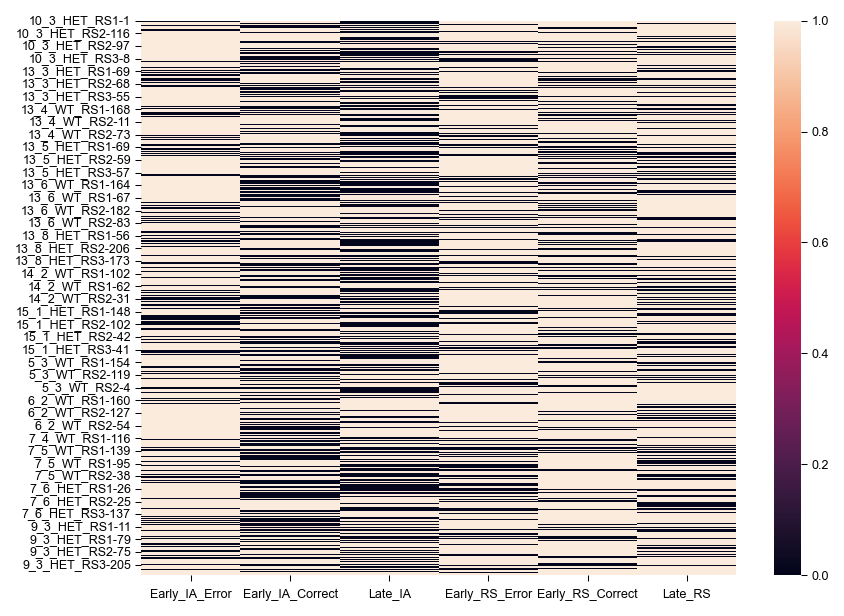

In [128]:
sns.heatmap(canon_less_new_mean.astype(float) == 0)

In [100]:
canon_spikes_df, canon_umap_spikes_model = run_umap_with_stage_labels( canon_spike_umap_input, stage_names, n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)

canon_spike_cell_enrich = canon_mean_unit_tseries.groupby(by = 'unique_ID')[stage_names].first().astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
canon_spikes_df = canon_spikes_df.merge(canon_spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)
canon_spikes_df

Base shape: (4776, 6)
Complete cases: (4776, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2,first_active_stage
unique_ID,,,
10_3_HET_RS1-1,14.955326,-13.225299,Early_IA_Error
10_3_HET_RS1-10,11.758310,-0.566257,Early_IA_Error
10_3_HET_RS1-101,-19.897745,22.507341,Never
10_3_HET_RS1-104,7.116478,2.665500,Late_IA
10_3_HET_RS1-107,5.358498,4.102057,Never
...,...,...,...
9_3_HET_RS3-95,14.932246,-13.145504,Never
9_3_HET_RS3-96,10.849854,-1.109410,Never
9_3_HET_RS3-97,14.383278,-0.421262,Early_IA_Error


In [98]:
canon_spikes_df

,UMAP1,UMAP2
unique_ID,,
10_3_HET_RS1-1,14.955326,-13.225299
10_3_HET_RS1-10,11.758310,-0.566257
10_3_HET_RS1-101,-19.897745,22.507341
10_3_HET_RS1-104,7.116478,2.665500
10_3_HET_RS1-107,5.358498,4.102057
...,...,...
9_3_HET_RS3-95,14.932246,-13.145504
9_3_HET_RS3-96,10.849854,-1.109410
9_3_HET_RS3-97,14.383278,-0.421262


In [99]:
canon_mean_unit_tseries.groupby(by = 'unique_ID')[stage_names].first().astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)

unique_ID
10_3_HET_RS1-1      Early_IA_Error
10_3_HET_RS1-10     Early_IA_Error
10_3_HET_RS1-101             Never
10_3_HET_RS1-104           Late_IA
10_3_HET_RS1-107             Never
                         ...      
9_3_HET_RS3-95               Never
9_3_HET_RS3-96               Never
9_3_HET_RS3-97      Early_IA_Error
9_3_HET_RS3-98               Never
9_3_HET_RS3-99               Never
Length: 4776, dtype: object

In [37]:
dff_df

,UMAP1,UMAP2,first_active_stage
neuron_id,,,
10_3_HET_RS1-1,12.622513,10.524050,Early_IA_Error
10_3_HET_RS1-10,11.150599,7.630769,Early_IA_Error
10_3_HET_RS1-100,5.013901,-0.784930,Never
10_3_HET_RS1-101,1.982271,1.774831,Never
10_3_HET_RS1-102,5.859055,0.542735,Never
...,...,...,...
9_3_HET_RS3-95,7.824842,6.792192,Never
9_3_HET_RS3-96,9.832567,4.483198,Never
9_3_HET_RS3-97,10.235147,10.320923,Early_IA_Error


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

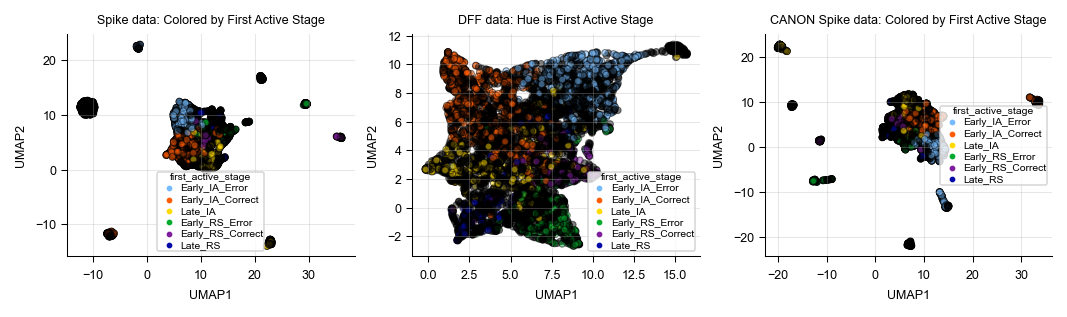

In [101]:
## PLOTTING- note that paper tSNE is projection of mean activity in stage, colored by ensemble identity
fig, axes = plt.subplots(1, 3, figsize=(7, 2), layout='constrained')
palette = [stage_palette_dict[x] for x in stage_names] + ['lightgray']
hue_col = 'first_active_stage'

# Spikes
sns.scatterplot(ax=axes[0], data=spikes_df, x='UMAP1', y='UMAP2', hue=hue_col,     palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',linewidth=0.5, legend='full')
axes[0].set_title(f'Spike data: Colored by First Active Stage')
axes[0].grid(True, alpha=0.3)
# Spikes- CANON
sns.scatterplot(ax=axes[2], data=canon_spikes_df, x='UMAP1', y='UMAP2', hue=hue_col,     palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',linewidth=0.5, legend='full')
axes[2].set_title(f'CANON Spike data: Colored by First Active Stage')
axes[2].grid(True, alpha=0.3)


# DFF
sns.scatterplot(ax=axes[1], data=dff_df, x='UMAP1', y='UMAP2', hue=hue_col, palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',  linewidth=0.5, legend='full')
axes[1].set_title(f'DFF data: Hue is First Active Stage')
axes[1].grid(True, alpha=0.3)

#Final check- save manifest of config

In [39]:
subjects= unit_mean_tseries['subject_name'].unique().tolist()
enrichment_output_path = "None"
timeseries_output_path= "None"

In [40]:
# Cell: Save run manifest
runtime = time.time() - START_TIME

manifest = create_run_manifest(
    config=config,
    output_dir=run_output_dir,
    run_id=RUN_ID,
    inputs={'source_data': str(config['data']['source_dataset_location']),'n_subjects': len(subjects),},
    outputs={'shuffle_parquets': str(run_output_dir),
        'n_files': len(list(run_output_dir.glob('*.parquet'))),
        'enrichment_results': str(enrichment_output_path),
        'timeseries_results': str(timeseries_output_path),
    },
    performance={'runtime_seconds': int(runtime),'runtime_human': f"{runtime/3600:.1f} hours",'n_cores_used': config['shuffles']['n_cores'],},
    status={'success': True,'errors': [],'warnings': [],}
)

# Update central run log
run_db = update_run_database(manifest, db_path=results_dir / 'run_log.csv')
print(f"Run complete: {RUN_ID}")
print(f"Runtime: {runtime/3600:.1f} hours")
print(f"Outputs: {run_output_dir}")
print(f"Manifest: {run_output_dir / f'run_manifest_{RUN_ID}.yaml'}")

[OK] Manifest saved to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251202_124320\run_manifest_20251202_124320.yaml
[OK] Run database updated: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\run_log.csv
     Total runs recorded: 13
Run complete: 20251202_124320
Runtime: 1.8 hours
Outputs: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251202_124320
Manifest: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251202_124320\run_manifest_20251202_124320.yaml
